# Project Introduction

##### Title:
Fraud Detection in Mobile Financial Transactions Using Machine Learning
##### Description:
Financial fraud in digital transactions has become a major concern for banks and fintech companies. With increasing online payments, fraudsters exploit system vulnerabilities to perform unauthorized transactions.
The objective of this project is to develop a robust machine learning model capable of accurately detecting fraudulent transactions in real-time. The project focuses not only on predictive performance but also on evaluating financial impact to support business decision-making.


# SECTION 1: Import Libraries

#### Importing Required Libraries
##### In this section, we import all necessary Python libraries required for data manipulation, visualization, model building, and performance evaluation.
We use:
•	Pandas & NumPy for data handling
•	Matplotlib & Seaborn for visualization
•	Scikit-learn for machine learning models
•	Imbalanced-learn for handling imbalanced data using SMOTE


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

from imblearn.over_sampling import SMOTE


# SECTION 2: Load Dataset

In [22]:
df = pd.read_csv('Fraud_Analysis_Dataset.csv')
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


# SECTION 3: Basic Data Inspection

The dataset is loaded using Pandas. We begin by inspecting:

•	Dataset shape

•	Data types

•	Null values

•	Statistical summary

This helps in understanding data structure and identifying potential preprocessing steps.


In [23]:
df.shape


(11142, 10)

In [24]:
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  str    
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  str    
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  str    
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), str(3)
memory usage: 870.6 KB


In [25]:
df.isnull().sum()


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [26]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,11142.000000,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,11142.000000
mean,8.717645,2.131915e+05,9.241173e+05,8.249576e+05,8.883541e+05,1.103211e+06,0.102495
std,16.067479,7.600650e+05,2.143004e+06,2.089894e+06,2.601376e+06,2.982447e+06,0.303312
min,1.000000,2.390000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2.000000,4.946618e+03,4.270000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,6.000000,1.676126e+04,2.816950e+04,4.420605e+03,0.000000e+00,0.000000e+00,0.000000
75%,7.000000,1.543366e+05,3.040855e+05,1.114126e+05,2.711555e+05,3.186374e+05,0.000000
max,95.000000,1.000000e+07,1.990000e+07,1.300000e+07,3.300000e+07,3.460000e+07,1.000000


In [27]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud'],
      dtype='str')

# SECTION 4: Check Class Imbalance

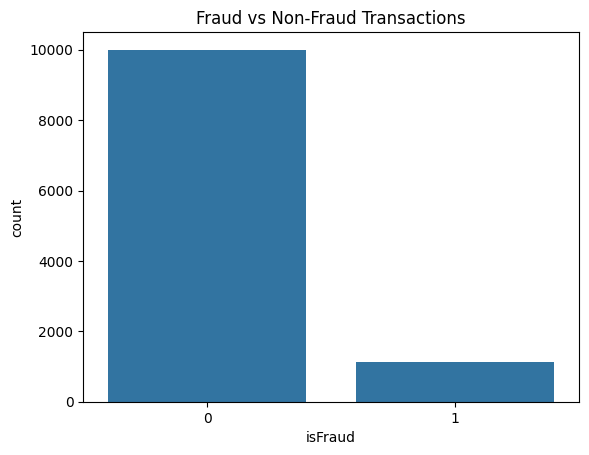

In [28]:
df['isFraud'].value_counts()

sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()


Fraud detection datasets are typically highly imbalanced. Therefore, we analyze the distribution of the target variable isFraud.

A strong imbalance indicates that accuracy alone is not a reliable evaluation metric.

Visualizing fraud vs non-fraud transactions helps us understand the scale of imbalance


# SECTION 5: Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps uncover patterns and relationships in the dataset.

We analyze:

•	Fraud distribution across transaction types

•	Transaction amount patterns

•	Balance changes before and after transactions

•	Correlation between numerical features

Key Observations:

•	Fraud mostly occurs in TRANSFER and CASH_OUT transactions.

•	Fraud transactions often result in zero or near-zero sender balance.

•	High transaction amounts are more frequently associated with fraud.


## Fraud by Transaction Type

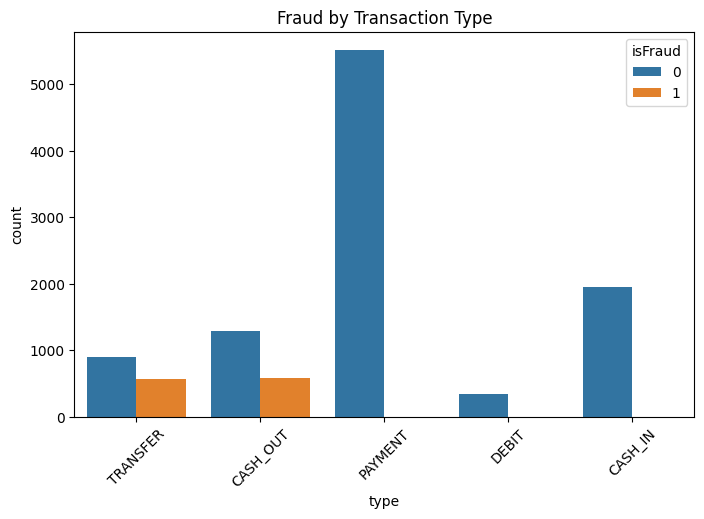

In [29]:
plt.figure(figsize=(8,5))
sns.countplot(x='type', hue='isFraud', data=df)
plt.title("Fraud by Transaction Type")
plt.xticks(rotation=45)
plt.show()


## Amount Distribution


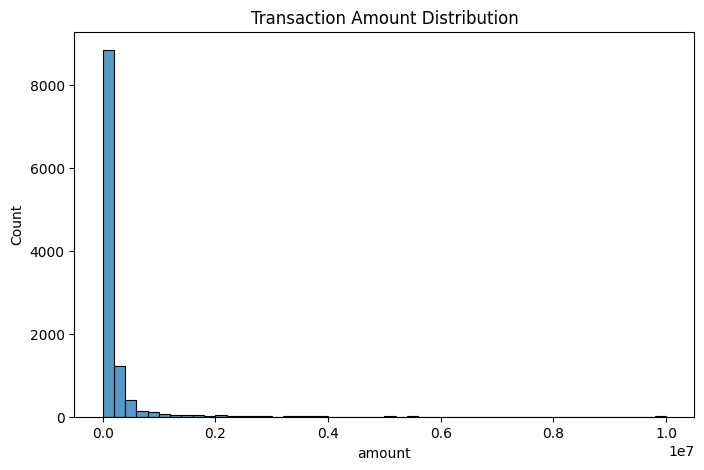

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df['amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()


# SECTION 6: Feature Engineering

In [31]:
df['balanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balanceDiffDest'] = df['newbalanceDest'] - df['oldbalanceDest']

df['errorOrig'] = df['amount'] - df['balanceDiffOrig']
df['errorDest'] = df['amount'] - df['balanceDiffDest']


To enhance model performance, new features were engineered based on transaction balance behavior.

The following features were created:

•	balanceDiffOrig: Difference in sender balance before and after transaction

•	balanceDiffDest: Difference in receiver balance before and after transaction

•	errorOrig: Difference between transaction amount and actual balance deduction

•	errorDest: Difference between transaction amount and receiver balance change

These features help detect inconsistencies commonly seen in fraudulent transactions.


# Data Preprocessing
Data preprocessing steps include:

•	Encoding categorical variable (transaction type)

•	Dropping identifier columns (nameOrig, nameDest)

•	Splitting dataset into features (X) and target (y)

•	Train-test split using stratification to maintain fraud ratio

Identifiers are removed as they do not provide predictive value and may introduce noise


# SECTION 7: Encode Categorical Variable

In [32]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)


# SECTION 8: Drop Unnecessary Columns

In [33]:
df = df.drop(['nameOrig', 'nameDest'], axis=1)


# SECTION 9: Define X (Features) & (Target) y

In [34]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']


# SECTION 10: Train-Test Split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
# stratify=y keeps fraud ratio same in train & test.


# SECTION 11: Apply SMOTE

In [36]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_sm.value_counts())
# dataset becomes balanced.

Before SMOTE: isFraud
0    7000
1     799
Name: count, dtype: int64
After SMOTE: isFraud
0    7000
1    7000
Name: count, dtype: int64


### Handling Imbalanced Data (SMOTE)

Fraud datasets are highly imbalanced, which can cause the model to bias toward majority class predictions.

To address this, SMOTE (Synthetic Minority Oversampling Technique) is applied to the training data.

SMOTE generates synthetic fraud samples to balance the dataset, improving the model’s ability to learn fraud patterns.

This ensures better recall and overall model reliability.


# SECTION 12: Scale Data (for Logistic Regression)

### Feature Scaling

Feature scaling is applied using StandardScaler to normalize numerical features.

Scaling improves the performance of machine learning algorithms, particularly distance-based models.


In [37]:
scaler = StandardScaler()
X_train_sm = scaler.fit_transform(X_train_sm)
X_test = scaler.transform(X_test)


# SECTION 13: Model Building

### Multiple machine learning models are implemented and compared:

•	Logistic Regression

•	Random Forest

•	Gradient Boosting

Comparing multiple models helps in selecting the most reliable and business-effective solution.


## Logistic Regression

In [38]:
lr = LogisticRegression()
lr.fit(X_train_sm, y_train_sm)

y_pred_lr = lr.predict(X_test)


## Random Forest

In [39]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)


## Gradient Boosting

In [40]:
gb = GradientBoostingClassifier()
gb.fit(X_train_sm, y_train_sm)

y_pred_gb = gb.predict(X_test)


# SECTION 14: Model Evaluation

### Model performance is evaluated using:

•	Precision

•	Recall

•	F1 Score

•	ROC-AUC

•	Confusion Matrix

In fraud detection:

•	False Negative (FN) = Fraud not detected → Financial Loss

•	False Positive (FP) = Legitimate transaction blocked → Customer inconvenience

Recall is particularly important as missing fraud cases results in direct financial impact


In [41]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

print("Gradient Boosting")
print(classification_report(y_test, y_pred_gb))
print("ROC AUC:", roc_auc_score(y_test, gb.predict_proba(X_test)[:,1]))


Logistic Regression
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3000
           1       0.98      0.93      0.95       343

    accuracy                           0.99      3343
   macro avg       0.99      0.96      0.97      3343
weighted avg       0.99      0.99      0.99      3343

ROC AUC: 0.9945335276967929
Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3000
           1       1.00      1.00      1.00       343

    accuracy                           1.00      3343
   macro avg       1.00      1.00      1.00      3343
weighted avg       1.00      1.00      1.00      3343

ROC AUC: 0.9999844509232264
Gradient Boosting
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3000
           1       1.00      1.00      1.00       343

    accuracy                           1.00      3343
   macro avg       1

# SECTION 15: Financial Impact Analysis (Important)

In [42]:
average_fraud_amount = df[df['isFraud']==1]['amount'].mean()

fn = confusion_matrix(y_test, y_pred_rf)[1][0]

expected_loss = fn * average_fraud_amount

print("Expected Financial Loss:", expected_loss)


Expected Financial Loss: 1192628.9320753065


Beyond model metrics, business impact analysis is conducted.

Expected Financial Loss is calculated as:

Expected Loss = False Negatives × Average Fraud Amount

This helps determine which model minimizes financial loss rather than simply maximizing accuracy.

The final model is selected based on:

•	High Recall

•	Strong ROC-AUC

•	Lowest estimated financial loss
